# Модуль 2. Данные и вероятность

Ноутбук к [модулю 2](https://drobyshevdev.github.io/lemma/modules/02-data-and-probability/).

Пять сюжетов, все на симуляции: центральная предельная теорема, происхождение корня из n, формула для числа зёрен против прямого перебора, Байес на редком событии и переобучение без единой модели.

Считается за секунды на CPU. Нужны `numpy` и `matplotlib`.

**Читайте дважды.** Первый раз сверху вниз, второй — ломая: в конце каждого раздела написано, что именно.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260803)

plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"numpy {np.__version__}")

numpy 1.26.4


## 1. Центральная предельная теорема

Утверждение из текста: среднее многих независимых величин распределено приблизительно нормально, **как бы ни было распределено каждое слагаемое**.

Возьмём распределение, максимально непохожее на колокол: бросок монеты, ноль или единица. Его гистограмма — два столбика.

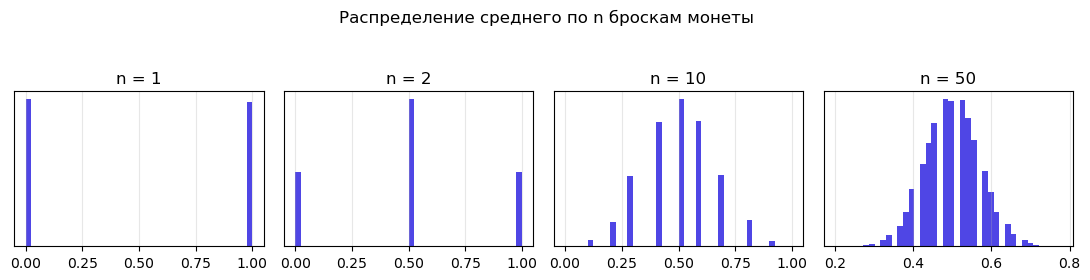

In [2]:
def sample_means(n, n_experiments=20_000, rng=RNG):
    """n_experiments средних, каждое по n броскам монеты."""
    draws = rng.integers(0, 2, size=(n_experiments, n))
    return draws.mean(axis=1)

fig, axes = plt.subplots(1, 4, figsize=(11, 2.6))
for ax, n in zip(axes, [1, 2, 10, 50]):
    ax.hist(sample_means(n), bins=40, color="#4f46e5", edgecolor="none")
    ax.set_title(f"n = {n}")
    ax.set_yticks([])
plt.suptitle("Распределение среднего по n броскам монеты", y=1.06)
plt.tight_layout()
plt.show()

При `n = 1` это исходное распределение: два столбика. При `n = 50` — колокол. Ничего нормального в монете нет; нормальность появляется от усреднения.

**Сломайте:** замените монету на `rng.exponential(1.0, size=...)` — распределение с длинным хвостом и заметной асимметрией. При каком `n` колокол становится похож на колокол? Асимметричным распределениям нужно больше.

## 2. Откуда берётся корень из n

Теорема обещает, что стандартное отклонение среднего равно $\sigma/\sqrt{n}$. Это проверяемое утверждение.

In [3]:
SIGMA = 4.0
rng = np.random.default_rng(1)

print("    n   измеренный разброс среднего   предсказание sigma/sqrt(n)")
for n in [1, 4, 16, 64, 256, 1024]:
    means = rng.normal(100, SIGMA, size=(20_000, n)).mean(axis=1)
    measured = means.std(ddof=1)
    predicted = SIGMA / np.sqrt(n)
    print(f"{n:>5}   {measured:>21.4f}   {predicted:>24.4f}")

    n   измеренный разброс среднего   предсказание sigma/sqrt(n)
    1                  3.9764                     4.0000
    4                  1.9740                     2.0000
   16                  1.0022                     1.0000
   64                  0.4973                     0.5000
  256                  0.2489                     0.2500


 1024                  0.1240                     0.1250


Совпадает до третьего знака на каждой строке. Обратите внимание на шаг: `n` растёт вчетверо, разброс падает вдвое.

Это и есть обменный курс из текста, и он не подлежит обсуждению — свойство арифметики, а не недоработка метода.

## 3. Сколько зёрен нужно

В модуле 1 ответ добывался перебором. Теперь есть формула:

$$n \approx 16\,\frac{\sigma^2}{\Delta^2}$$

Проверим её тем же перебором. Формула обещает обнаружение эффекта примерно в 80 % случаев.

In [4]:
def required_n(delta, sigma):
    return int(np.ceil(16 * sigma ** 2 / delta ** 2))

def detection_rate(delta, sigma, n, n_experiments=20_000, seed=0):
    """Доля экспериментов, где разница признана показанной.

    Критерий тот же, что в модуле 1: интервалы разницы не накрывают ноль.
    """
    rng = np.random.default_rng(seed)
    a = rng.normal(0.0, sigma, size=(n_experiments, n))
    b = rng.normal(delta, sigma, size=(n_experiments, n))
    diff = b.mean(axis=1) - a.mean(axis=1)
    se = np.sqrt(a.var(axis=1, ddof=1) / n + b.var(axis=1, ddof=1) / n)
    return float((diff - 1.96 * se > 0).mean())

print("delta  sigma    n по формуле   реально обнаружено")
for delta, sigma in [(2.0, 4.0), (1.0, 4.0), (4.0, 4.0), (2.0, 2.0)]:
    n = required_n(delta, sigma)
    print(f"{delta:>5.1f}  {sigma:>5.1f}   {n:>12}   {detection_rate(delta, sigma, n):>17.1%}")

delta  sigma    n по формуле   реально обнаружено
  2.0    4.0             64               80.5%


  1.0    4.0            256               80.5%
  4.0    4.0             16               80.7%
  2.0    2.0             16               80.7%


Формула держит обещание: около 80 % во всех четырёх случаях.

Теперь посмотрите на первую строку. При $\Delta = 2$ и $\sigma = 4$ нужно **64 запуска каждого метода**. В статьях обычно три.

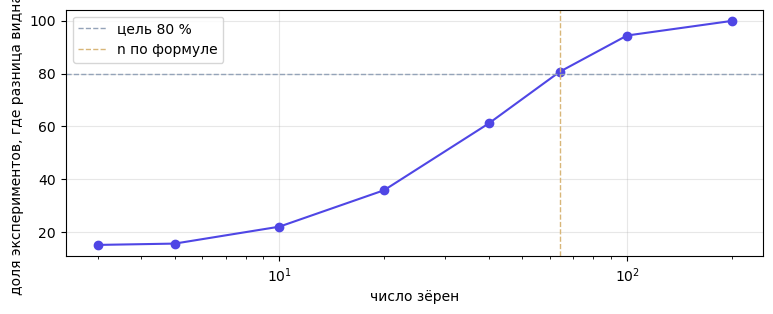

при 3 зёрнах разницу видно в 15% экспериментов


In [5]:
delta, sigma = 2.0, 4.0
ns = [3, 5, 10, 20, 40, 64, 100, 200]
rates = [detection_rate(delta, sigma, n, seed=2) for n in ns]

fig, ax = plt.subplots()
ax.plot(ns, [100 * r for r in rates], marker="o", color="#4f46e5")
ax.axhline(80, color="#94a3b8", ls="--", lw=1, label="цель 80 %")
ax.axvline(required_n(delta, sigma), color="#d8b678", ls="--", lw=1, label="n по формуле")
ax.set_xscale("log")
ax.set_xlabel("число зёрен")
ax.set_ylabel("доля экспериментов, где разница видна, %")
ax.legend()
plt.show()

print(f"при 3 зёрнах разницу видно в {detection_rate(delta, sigma, 3, seed=2):.0%} экспериментов")

**Сломайте:** посчитайте `required_n` для эффекта в 0.5 при том же разбросе. Число вас удивит — и объяснит, почему мелкие улучшения так трудно доказать.

## 4. Байес на редком событии

Тест находит болезнь у больного в 99 % случаев и ошибается на здоровом в 5 %. Болезнь у одного из тысячи. Тест положительный.

In [6]:
def posterior(prevalence, sensitivity=0.99, false_positive=0.05):
    """P(болен | тест положительный) по формуле Байеса."""
    p_pos = sensitivity * prevalence + false_positive * (1 - prevalence)
    return sensitivity * prevalence / p_pos

print(f"по формуле: {posterior(0.001):.4f}")

# Та же величина честным пересчётом людей, без формулы вообще.
N = 1_000_000
rng = np.random.default_rng(3)
sick = rng.random(N) < 0.001
positive = np.where(sick, rng.random(N) < 0.99, rng.random(N) < 0.05)
print(f"пересчётом:  {sick[positive].mean():.4f}")
print()
print(f"положительных всего: {positive.sum():,}")
print(f"из них действительно больны: {(sick & positive).sum():,}")

по формуле: 0.0194
пересчётом:  0.0189

положительных всего: 50,628
из них действительно больны: 959


Меньше двух процентов. Дело не в качестве теста, а в редкости болезни: здоровых так много, что даже 5 % ошибок на них дают больше положительных, чем все больные вместе.

Посмотрим, при какой распространённости тест начинает что-то значить.

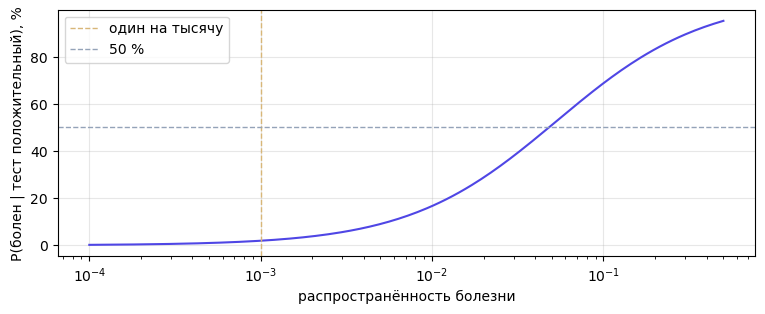

Тот же тест, разная распространённость:
    0.1% больных  ->  1.9% после положительного теста
    1.0% больных  ->  16.7% после положительного теста
    5.0% больных  ->  51.0% после положительного теста
   20.0% больных  ->  83.2% после положительного теста
   50.0% больных  ->  95.2% после положительного теста


In [7]:
prev = np.logspace(-4, -0.3, 200)

fig, ax = plt.subplots()
ax.plot(prev, 100 * posterior(prev), color="#4f46e5")
ax.axvline(0.001, color="#d8b678", ls="--", lw=1, label="один на тысячу")
ax.axhline(50, color="#94a3b8", ls="--", lw=1, label="50 %")
ax.set_xscale("log")
ax.set_xlabel("распространённость болезни")
ax.set_ylabel("P(болен | тест положительный), %")
ax.legend()
plt.show()

print("Тот же тест, разная распространённость:")
for p in [0.001, 0.01, 0.05, 0.2, 0.5]:
    print(f"  {p:>6.1%} больных  ->  {posterior(p):.1%} после положительного теста")

Один и тот же тест даёт от 2 % до 95 % уверенности. Меняется не тест — меняется то, что мы знали **до** него.

Это же происходит с классификатором на несбалансированных данных, с детектором мошенничества и с любым фильтром, который ищет иголку.

**Сломайте:** сделайте тест идеальным по чувствительности (`sensitivity=1.0`), оставив 5 % ложных срабатываний. Сильно ли поможет? А теперь наоборот: `false_positive=0.001` при `sensitivity=0.9`. Какой из двух параметров решает на редком событии?

## 5. Переобучение без единой модели

Слово «модель» здесь не понадобится. Только многочлен и пятнадцать точек с шумом.

Истина простая — синусоида. Данные — истина плюс шум. Подгоняем многочлен растущей степени и смотрим на ошибку **на новых точках**, которых при подгонке не было.

In [8]:
def truth(x):
    return np.sin(2 * np.pi * x)

rng = np.random.default_rng(7)
N_TRAIN, NOISE = 15, 0.25

x_train = np.sort(rng.random(N_TRAIN))
y_train = truth(x_train) + rng.normal(0, NOISE, N_TRAIN)

x_new = np.sort(rng.random(500))
y_new = truth(x_new) + rng.normal(0, NOISE, 500)

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

degrees = range(0, 15)
err_train, err_new = [], []
for d in degrees:
    coeffs = np.polyfit(x_train, y_train, d)
    err_train.append(rmse(np.polyval(coeffs, x_train), y_train))
    err_new.append(rmse(np.polyval(coeffs, x_new), y_new))

print("степень   ошибка на своих   ошибка на новых")
for d, a, b in zip(degrees, err_train, err_new):
    mark = "  <- лучшая на новых" if b == min(err_new) else ""
    print(f"{d:>7}   {a:>15.3f}   {b:>15.3f}{mark}")

степень   ошибка на своих   ошибка на новых
      0             0.726             0.754
      1             0.380             0.519
      2             0.354             0.542
      3             0.198             0.303  <- лучшая на новых
      4             0.157             0.369
      5             0.150             0.472
      6             0.149             0.437
      7             0.147             0.365
      8             0.147             0.415
      9             0.139             4.811
     10             0.139             5.020
     11             0.138            28.511
     12             0.077           347.430
     13             0.034           437.149
     14             0.000         13243.232


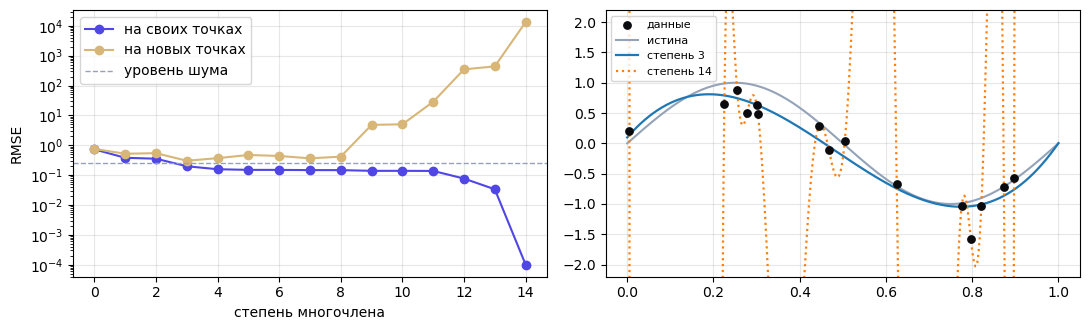

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))

ax1.plot(degrees, err_train, marker="o", label="на своих точках", color="#4f46e5")
ax1.plot(degrees, err_new, marker="o", label="на новых точках", color="#d8b678")
ax1.axhline(NOISE, color="#94a3b8", ls="--", lw=1, label="уровень шума")
ax1.set_yscale("log")
ax1.set_xlabel("степень многочлена")
ax1.set_ylabel("RMSE")
ax1.legend()

grid = np.linspace(0, 1, 400)
ax2.scatter(x_train, y_train, s=28, color="#0a0b0e", zorder=3, label="данные")
ax2.plot(grid, truth(grid), color="#94a3b8", lw=1.5, label="истина")
for d, style in [(3, "-"), (14, ":")]:
    ax2.plot(grid, np.polyval(np.polyfit(x_train, y_train, d), grid),
             style, lw=1.6, label=f"степень {d}")
ax2.set_ylim(-2.2, 2.2)
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

Ошибка на своих точках падает до нуля: многочлен степени 14 проходит ровно через все пятнадцать. Ошибка на новых точках сначала падает, потом взлетает.

На правом графике видно, чем он занят между точками. Он не выучил синусоиду — он выучил **эти пятнадцать шумов**, а шум в новых данных другой.

Обратите внимание на серую линию: лучшая достижимая ошибка на новых данных равна уровню шума. Ниже неё не опустится ничто, потому что шум непредсказуем по определению. Метод, показавший ошибку ниже этой линии на новых данных, не гениален — у него утечка.

**Сломайте:** увеличьте `N_TRAIN` до 200. При какой степени теперь начинается переобучение? Затем верните 15 и поставьте `NOISE = 0.01`. Что происходит с разрывом между кривыми?

## Итог

Что посчитано, а не принято на веру:

1. Среднее становится нормальным даже из монеты — колокол берётся из усреднения, а не из данных.
2. Разброс среднего равен $\sigma/\sqrt{n}$ с точностью до третьего знака.
3. Формула $n \approx 16\sigma^2/\Delta^2$ даёт обещанные 80 % обнаружения.
4. Хороший тест на редкое событие даёт в основном ложные срабатывания, и решает распространённость, а не качество теста.
5. Подгонка под шум видна как разрыв между ошибкой на своих и на новых точках, и лучшая достижимая ошибка равна уровню шума.

Дальше — [модуль 3](https://drobyshevdev.github.io/lemma/programme/): линейная алгебра как язык, с регрессией и PCA в качестве первых применений.